## Import Packages

In [227]:
import yfinance as yf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind, f_oneway

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Import Ensemble models
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor 

from sklearn.metrics import classification_report, accuracy_score
import cvxpy as cp
import re

from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from matplotlib import cm
from sklearn.metrics import precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from statsmodels.tsa.stattools import ccf

## I. PCA Analysis

### 1. Fetch data for the FAANG stocks plus additional promising stocks

In [139]:
tickers = ['AAPL', 'AMZN', 'NFLX', 'GOOGL', 'NVDA', 'LLY', 'CMG', 'MCK', 'SMCI', 'MSFT', 'DIS', 'MCD', 'AVGO', 'NOW', 'MELI', 'GS', 'KNSL', 'ARGX']
start_date = '2015-01-01'
end_date = '2024-08-01'

data = yf.download(tickers, start=start_date, end=end_date)

[*********************100%%**********************]  18 of 18 completed


### 2. Feature Engineering

In [142]:
def calculate_technical_indicators(df):
    # Calculate returns
    df['Return'] = df['Adj Close'].pct_change() * 100
    
    # Calculate moving averages
    df['20d_MA'] = df['Adj Close'].rolling(window=20).mean()
    df['50d_MA'] = df['Adj Close'].rolling(window=50).mean()
    
    # Calculate volatility
    df['20d_Volatility'] = df['Return'].rolling(window=20).std()
    
    # Calculate Bollinger Bands
    df['20d_MA'] = df['Adj Close'].rolling(window=20).mean()
    df['20d_SD'] = df['Adj Close'].rolling(window=20).std()
    df['Upper_BB'] = df['20d_MA'] + (df['20d_SD']*2)
    df['Lower_BB'] = df['20d_MA'] - (df['20d_SD']*2)
    
    # Calculate RSI
    delta = df['Adj Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    RS = gain / loss
    df['RSI'] = 100 - (100 / (1 + RS))
    
    # Calculate MACD
    df['12d_EMA'] = df['Adj Close'].ewm(span=12, adjust=False).mean()
    df['26d_EMA'] = df['Adj Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['12d_EMA'] - df['26d_EMA']
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # Calculate OBV
    df['OBV'] = (np.sign(df['Adj Close'].diff()) * df['Volume']).fillna(0).cumsum()
    
    # Calculate ATR
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Adj Close'].shift())
    low_close = np.abs(df['Low'] - df['Adj Close'].shift())
    df['TR'] = high_low.combine(high_close, np.maximum).combine(low_close, np.maximum)
    df['ATR'] = df['TR'].rolling(window=14).mean()
    
    # Calculate Williams %R
    highest_high = df['High'].rolling(window=14).max()
    lowest_low = df['Low'].rolling(window=14).min()
    df['Williams_%R'] = (highest_high - df['Adj Close']) / (highest_high - lowest_low) * -100
    
    return df

# Calculate features for all tickers
features = pd.DataFrame()

# Using verified tickers from data columns
verified_tickers = data.columns.levels[1]

for ticker in verified_tickers:
    stock_data = data.xs(ticker, level=1, axis=1).copy()
    stock_data = calculate_technical_indicators(stock_data)
    stock_data = stock_data[['Return', '20d_MA', '50d_MA', '20d_Volatility', 'Upper_BB', 'Lower_BB', 'RSI', 'MACD', 'Signal_Line', 'OBV', 'ATR', 'Williams_%R']]
    stock_data.columns = [f'{ticker}_{col}' for col in stock_data.columns]
    if features.empty:
        features = stock_data
    else:
        features = features.join(stock_data)


### 3. Combine Features for Each Ticker

In [145]:
features = pd.DataFrame()

for ticker in verified_tickers:
    stock_data = data.xs(ticker, level=1, axis=1).copy()
    stock_data = calculate_technical_indicators(stock_data)
    stock_data = stock_data[['Return', '20d_MA', '50d_MA', '20d_Volatility', 'Upper_BB', 'Lower_BB', 'RSI', 'MACD', 'Signal_Line', 'OBV', 'ATR', 'Williams_%R']]
    stock_data.columns = [f'{ticker}_{col}' for col in stock_data.columns]
    if features.empty:
        features = stock_data
    else:
        features = features.join(stock_data)

features.dropna(inplace=True)
features.head()


,AAPL_Return,AAPL_20d_MA,AAPL_50d_MA,AAPL_20d_Volatility,AAPL_Upper_BB,AAPL_Lower_BB,AAPL_RSI,AAPL_MACD,AAPL_Signal_Line,AAPL_OBV,...,SMCI_50d_MA,SMCI_20d_Volatility,SMCI_Upper_BB,SMCI_Lower_BB,SMCI_RSI,SMCI_MACD,SMCI_Signal_Line,SMCI_OBV,SMCI_ATR,SMCI_Williams_%R
Date,,,,,,,,,,,,,,,,,,,,,
2017-07-28,-0.704044,34.649776,34.869707,0.775314,36.238668,33.060883,66.017187,0.284572,0.197097,1.067372e+09,...,24.941,2.327335,27.924526,23.520474,66.013065,0.569742,0.486920,608900.0,0.830000,-23.738900
2017-07-31,-0.515007,34.704888,34.851875,0.791573,36.230783,33.178992,61.299484,0.237739,0.205226,9.879888e+08,...,25.006,2.307289,28.028734,23.636266,65.100670,0.572352,0.504006,1016500.0,0.837143,-26.785703
2017-08-01,0.887475,34.781529,34.837787,0.797195,36.221447,33.341611,64.112656,0.222978,0.208776,1.129463e+09,...,25.064,2.289841,28.129571,23.800430,60.606057,0.587817,0.520768,1396600.0,0.787143,-18.181818
2017-08-02,4.725116,34.934227,34.852531,1.284488,36.538416,33.330038,73.044761,0.341230,0.235267,1.409210e+09,...,25.116,2.293221,28.161245,24.028756,54.545463,0.581269,0.532868,1039100.0,0.762857,-23.636350
2017-08-03,-0.999106,35.084467,34.860815,1.287682,36.646532,33.522402,65.826580,0.400680,0.268350,1.300821e+09,...,25.176,2.236139,28.091624,24.408377,51.327430,0.577491,0.541793,1540000.0,0.762857,-20.000042


### 4. Feature Selection

#### 4.1 Correlation Analysis

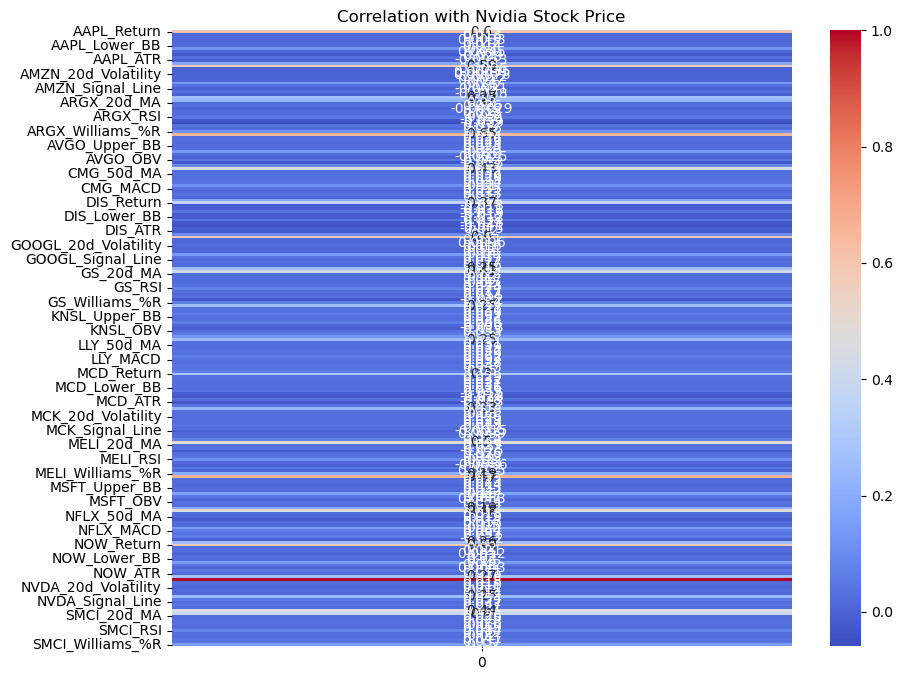

In [149]:
correlation_matrix = features.corrwith(features['NVDA_Return'])

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Nvidia Stock Price')
plt.show()

In [151]:
# Drop features with low correlation (absolute value less than 0.1)
low_correlation_features = correlation_matrix[correlation_matrix.abs() < 0.1].index
features.drop(columns=low_correlation_features, inplace=True)

#### 4.2 Statistical Tests

In [154]:
# Prepare DataFrame for statistical tests
combined_data = features.copy()
combined_data['NVDA'] = features['NVDA_Return']

# List of remaining features
remaining_features = features.columns

# Perform t-tests for each feature
for feature in remaining_features:
    if feature == 'NVDA_Return':
        continue
    high_group = combined_data[combined_data[feature] > combined_data[feature].median()]['NVDA']
    low_group = combined_data[combined_data[feature] <= combined_data[feature].median()]['NVDA']
    t_stat, p_value = ttest_ind(high_group, low_group)
    print(f'T-test for {feature}: t-statistic = {t_stat}, p-value = {p_value}')
    if p_value > 0.05:
        features.drop(columns=[feature], inplace=True)

# Perform ANOVA for each feature divided into quartiles
for feature in remaining_features:
    if feature == 'NVDA_Return' or feature not in features.columns:
        continue
    combined_data[f'{feature}_quartile'] = pd.qcut(combined_data[feature], 4, labels=False)
    anova_result = f_oneway(
        combined_data[combined_data[f'{feature}_quartile'] == 0]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 1]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 2]['NVDA'],
        combined_data[combined_data[f'{feature}_quartile'] == 3]['NVDA']
    )
    print(f'ANOVA for {feature} quartiles: F-statistic = {anova_result.statistic}, p-value = {anova_result.pvalue}')
    if anova_result.pvalue > 0.05:
        features.drop(columns=[feature], inplace=True)

T-test for AAPL_Return: t-statistic = 19.90685200838763, p-value = 1.0759638472437033e-79
T-test for AAPL_RSI: t-statistic = 3.380757647764079, p-value = 0.0007386602926249326
T-test for AAPL_Williams_%R: t-statistic = 6.689345613068914, p-value = 3.0017576631676746e-11
T-test for AMZN_Return: t-statistic = 20.545625906346533, p-value = 2.9349110909908505e-84
T-test for AMZN_RSI: t-statistic = 4.140467757559016, p-value = 3.629877698529793e-05
T-test for AMZN_Williams_%R: t-statistic = 8.01186723990233, p-value = 2.0358686637737413e-15
T-test for ARGX_Return: t-statistic = 10.092853565572215, p-value = 2.5245228628921823e-23
T-test for ARGX_Williams_%R: t-statistic = 3.252859044186372, p-value = 0.001164122959592504
T-test for AVGO_Return: t-statistic = 23.044658525051965, p-value = 6.434032383990392e-103
T-test for AVGO_RSI: t-statistic = 4.829363471818059, p-value = 1.4882682313257867e-06
T-test for CMG_Return: t-statistic = 14.738660604281762, p-value = 1.8900501584465057e-46
T-test

### 5. Train-Test Splitting and Normalization

In [158]:
train_features, test_features = train_test_split(features, test_size=0.2, random_state=42)
scaler = StandardScaler()
train_features_normalized = scaler.fit_transform(train_features)
test_features_normalized = scaler.transform(test_features)


### 6. Perform PCA Analysis

29 principal components explain 95% of the variance


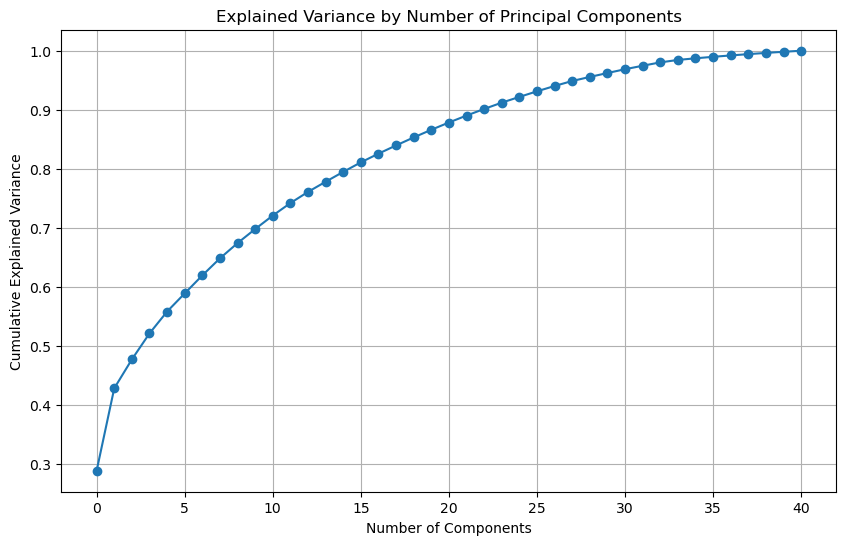

In [161]:
pca = PCA(random_state=42)
pca.fit(train_features_normalized)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
num_components = np.where(explained_variance >= 0.95)[0][0] + 1

print(f'{num_components} principal components explain 95% of the variance')

plt.figure(figsize=(10, 6))
plt.plot(explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Principal Components')
plt.grid()
plt.show()


### 7. Interpret Principal Components

                        PC1       PC2       PC3       PC4       PC5       PC6  \
AAPL_Return       -0.174129  0.231969 -0.013040 -0.071368  0.055907  0.021827   
AAPL_RSI          -0.170002 -0.162152  0.083118 -0.146026 -0.058332  0.103261   
AAPL_Williams_%R  -0.140635 -0.055014  0.431634 -0.018301  0.305057  0.013164   
AMZN_Return       -0.172936  0.197721 -0.156769 -0.056419  0.227976 -0.022314   
AMZN_RSI          -0.183365 -0.190617 -0.149248 -0.066064 -0.079513 -0.065933   
AMZN_Williams_%R  -0.209800 -0.115849 -0.083449 -0.026229  0.074694 -0.098444   
ARGX_Return       -0.068541  0.102246 -0.121796  0.145816 -0.073210  0.246752   
ARGX_Williams_%R  -0.096259 -0.027558 -0.053437  0.239788 -0.126854  0.220734   
AVGO_Return       -0.152792  0.222108  0.014403 -0.130502 -0.010143  0.075527   
AVGO_RSI          -0.146335 -0.131153  0.129503 -0.285270 -0.060884  0.103302   
CMG_Return        -0.133513  0.165041 -0.040224  0.114477  0.062683  0.015814   
CMG_RSI           -0.165475 

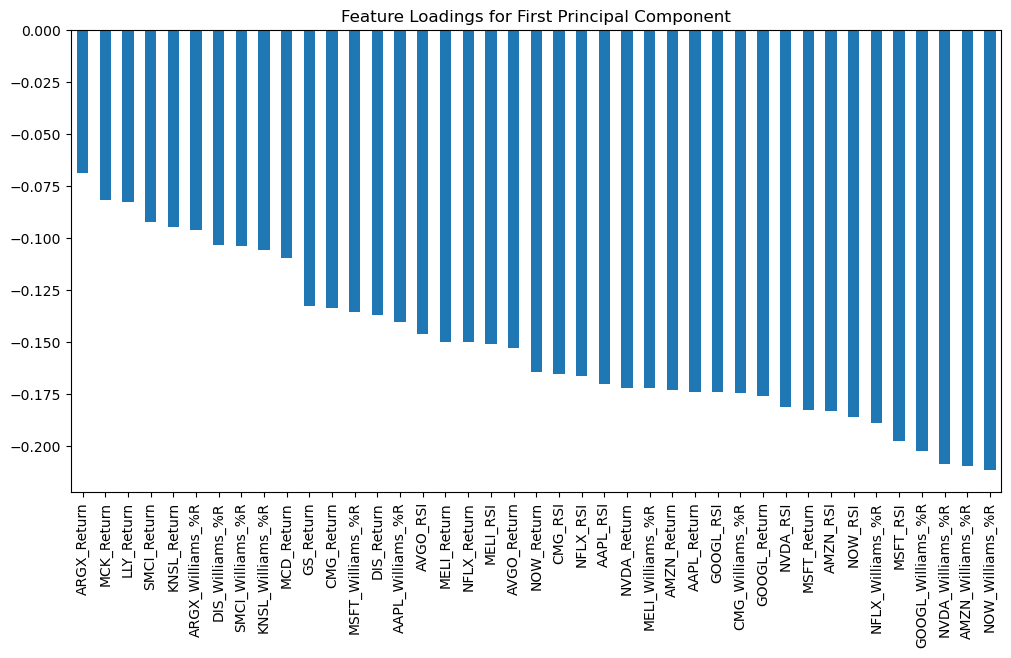

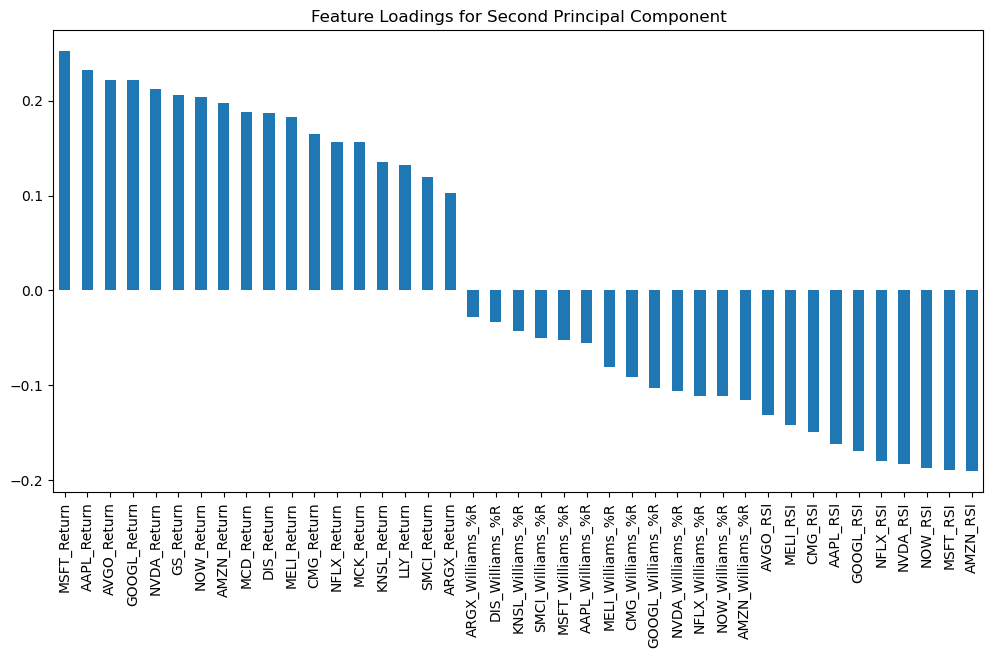

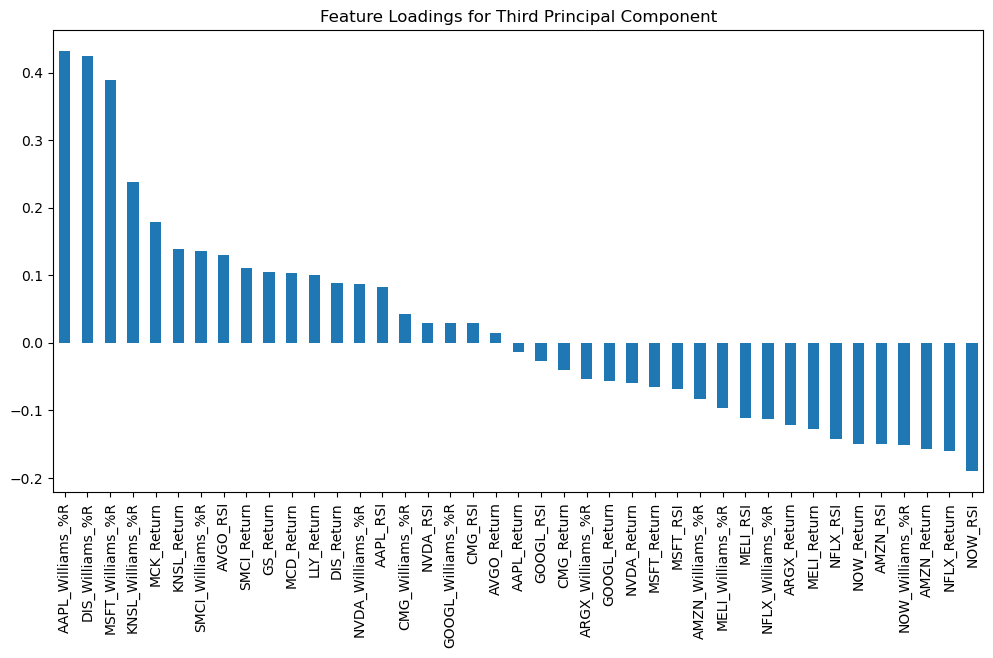

In [164]:
pcs = pca.components_
feature_names = train_features.columns

loadings = pd.DataFrame(pcs.T, columns=[f'PC{i+1}' for i in range(pcs.shape[0])], index=feature_names)

# Display the loadings for the first few principal components
print(loadings.iloc[:, :num_components])

# Plot the loadings for the first principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 0].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for First Principal Component')
plt.show()

# Plot the loadings for the second principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 1].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for Second Principal Component')
plt.show()

# Plot the loadings for the third principal component
plt.figure(figsize=(12, 6))
loadings.iloc[:, 2].sort_values(ascending=False).plot(kind='bar', title='Feature Loadings for Third Principal Component')
plt.show()



In [166]:
# PCA Results
explained_variance = pca.explained_variance_ratio_
loadings = pca.components_

In [168]:
# Extract feature columns
feature_cols = features.columns

C:\Users\ameet\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


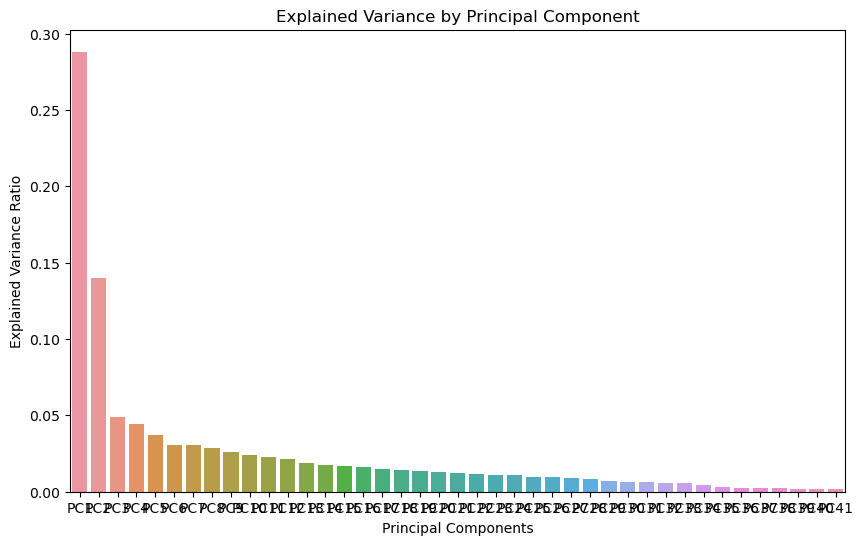

                        PC1       PC2       PC3       PC4       PC5       PC6  \
AAPL_Return       -0.174129  0.231969 -0.013040 -0.071368  0.055907  0.021827   
AAPL_RSI          -0.170002 -0.162152  0.083118 -0.146026 -0.058332  0.103261   
AAPL_Williams_%R  -0.140635 -0.055014  0.431634 -0.018301  0.305057  0.013164   
AMZN_Return       -0.172936  0.197721 -0.156769 -0.056419  0.227976 -0.022314   
AMZN_RSI          -0.183365 -0.190617 -0.149248 -0.066064 -0.079513 -0.065933   
AMZN_Williams_%R  -0.209800 -0.115849 -0.083449 -0.026229  0.074694 -0.098444   
ARGX_Return       -0.068541  0.102246 -0.121796  0.145816 -0.073210  0.246752   
ARGX_Williams_%R  -0.096259 -0.027558 -0.053437  0.239788 -0.126854  0.220734   
AVGO_Return       -0.152792  0.222108  0.014403 -0.130502 -0.010143  0.075527   
AVGO_RSI          -0.146335 -0.131153  0.129503 -0.285270 -0.060884  0.103302   
CMG_Return        -0.133513  0.165041 -0.040224  0.114477  0.062683  0.015814   
CMG_RSI           -0.165475 

In [170]:
# Create a DataFrame for loadings
loadings_df = pd.DataFrame(loadings.T, index=feature_cols, columns=[f'PC{i+1}' for i in range(loadings.shape[0])])

# Plot explained variance
plt.figure(figsize=(10, 6))
sns.barplot(x=[f'PC{i+1}' for i in range(len(explained_variance))], y=explained_variance)
plt.title('Explained Variance by Principal Component')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

# Show loadings
print(loadings_df)

### 8. Get all Feature Loadings

In [173]:
# Get the loadings
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=features.columns)

# Display the loadings
print("PCA Loadings:")
print(loadings)

PCA Loadings:
                        PC1       PC2       PC3       PC4       PC5       PC6  \
AAPL_Return       -0.174129  0.231969 -0.013040 -0.071368  0.055907  0.021827   
AAPL_RSI          -0.170002 -0.162152  0.083118 -0.146026 -0.058332  0.103261   
AAPL_Williams_%R  -0.140635 -0.055014  0.431634 -0.018301  0.305057  0.013164   
AMZN_Return       -0.172936  0.197721 -0.156769 -0.056419  0.227976 -0.022314   
AMZN_RSI          -0.183365 -0.190617 -0.149248 -0.066064 -0.079513 -0.065933   
AMZN_Williams_%R  -0.209800 -0.115849 -0.083449 -0.026229  0.074694 -0.098444   
ARGX_Return       -0.068541  0.102246 -0.121796  0.145816 -0.073210  0.246752   
ARGX_Williams_%R  -0.096259 -0.027558 -0.053437  0.239788 -0.126854  0.220734   
AVGO_Return       -0.152792  0.222108  0.014403 -0.130502 -0.010143  0.075527   
AVGO_RSI          -0.146335 -0.131153  0.129503 -0.285270 -0.060884  0.103302   
CMG_Return        -0.133513  0.165041 -0.040224  0.114477  0.062683  0.015814   
CMG_RSI       

### 9. Identify the Top Features for Each Principal Component

In [176]:
top_n = 5  # Number of top features to display
top_features = {}

for i in range(5):  # Loop through the first 5 principal components
    pc_name = f'PC{i+1}'
    top_features[pc_name] = loadings[pc_name].abs().sort_values(ascending=False).head(top_n).index.tolist()

# Step 5: Display the Top Features for Each Principal Component
print("Top Features for Each Principal Component:")
for pc, s_features in top_features.items():
    print(f"{pc}: {s_features}")

Top Features for Each Principal Component:
PC1: ['NOW_Williams_%R', 'AMZN_Williams_%R', 'NVDA_Williams_%R', 'GOOGL_Williams_%R', 'MSFT_RSI']
PC2: ['MSFT_Return', 'AAPL_Return', 'AVGO_Return', 'GOOGL_Return', 'NVDA_Return']
PC3: ['AAPL_Williams_%R', 'DIS_Williams_%R', 'MSFT_Williams_%R', 'KNSL_Williams_%R', 'NOW_RSI']
PC4: ['MELI_Williams_%R', 'MELI_RSI', 'CMG_Williams_%R', 'NVDA_RSI', 'AVGO_RSI']
PC5: ['MSFT_Williams_%R', 'KNSL_Return', 'MCK_Return', 'AAPL_Williams_%R', 'MCD_Return']


### 10. Plot the Loadings for the First Two Principal Components

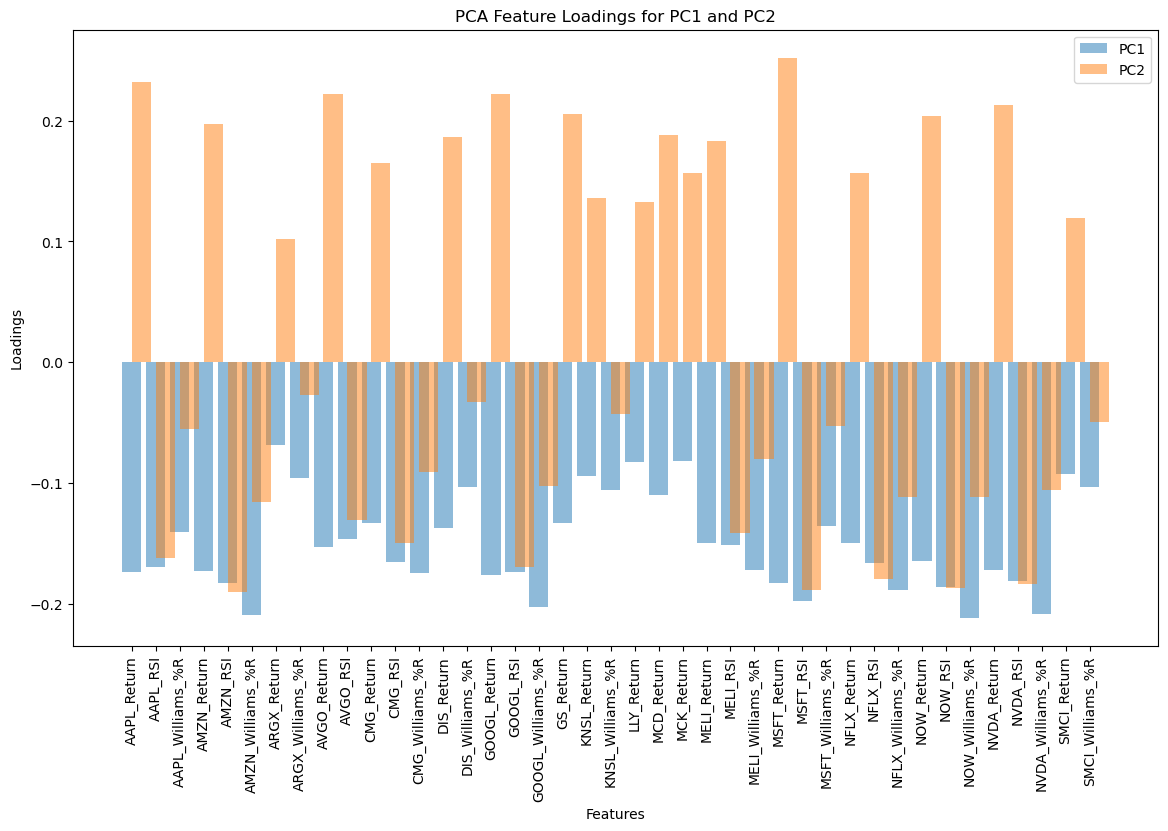

In [179]:
plt.figure(figsize=(14, 8))
plt.bar(loadings.index, loadings['PC1'], alpha=0.5, label='PC1', align='center')
plt.bar(loadings.index, loadings['PC2'], alpha=0.5, label='PC2', align='edge')
plt.xlabel('Features')
plt.ylabel('Loadings')
plt.title('PCA Feature Loadings for PC1 and PC2')
plt.legend()
plt.xticks(rotation=90)
plt.show()

### 11. Plot the Top Features for Each Principal Component

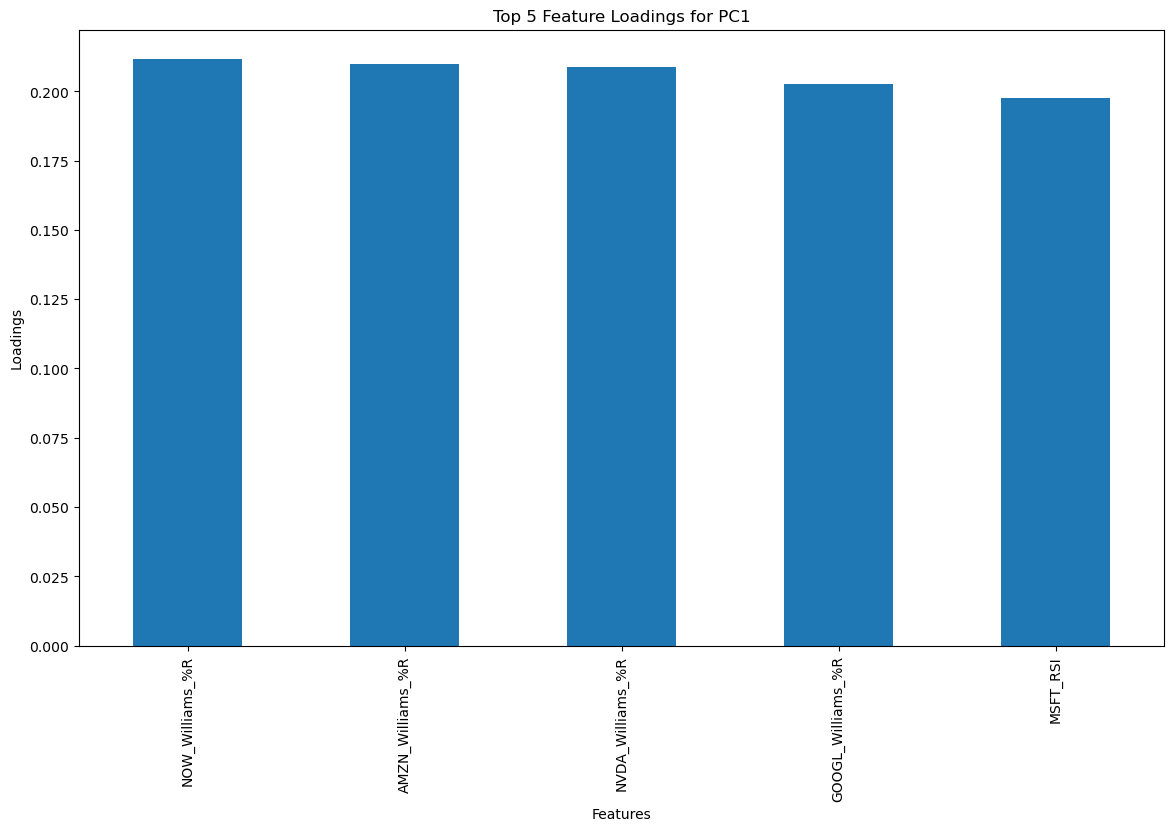

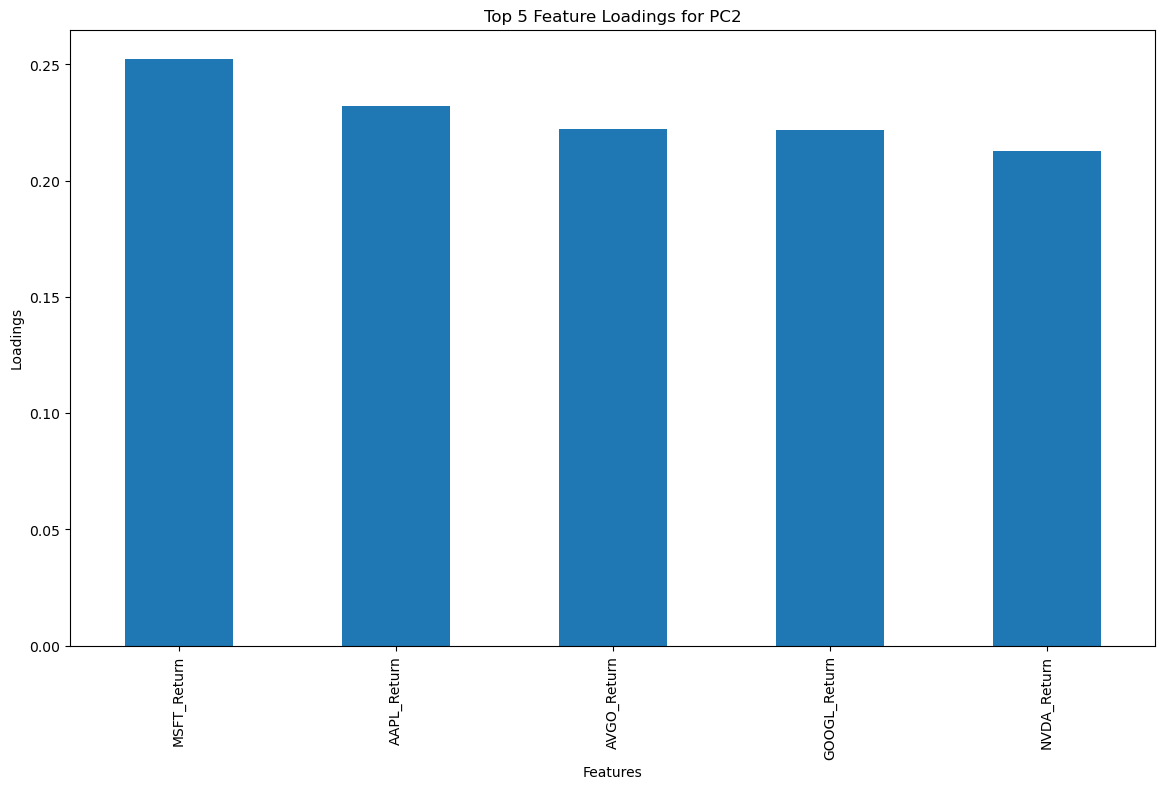

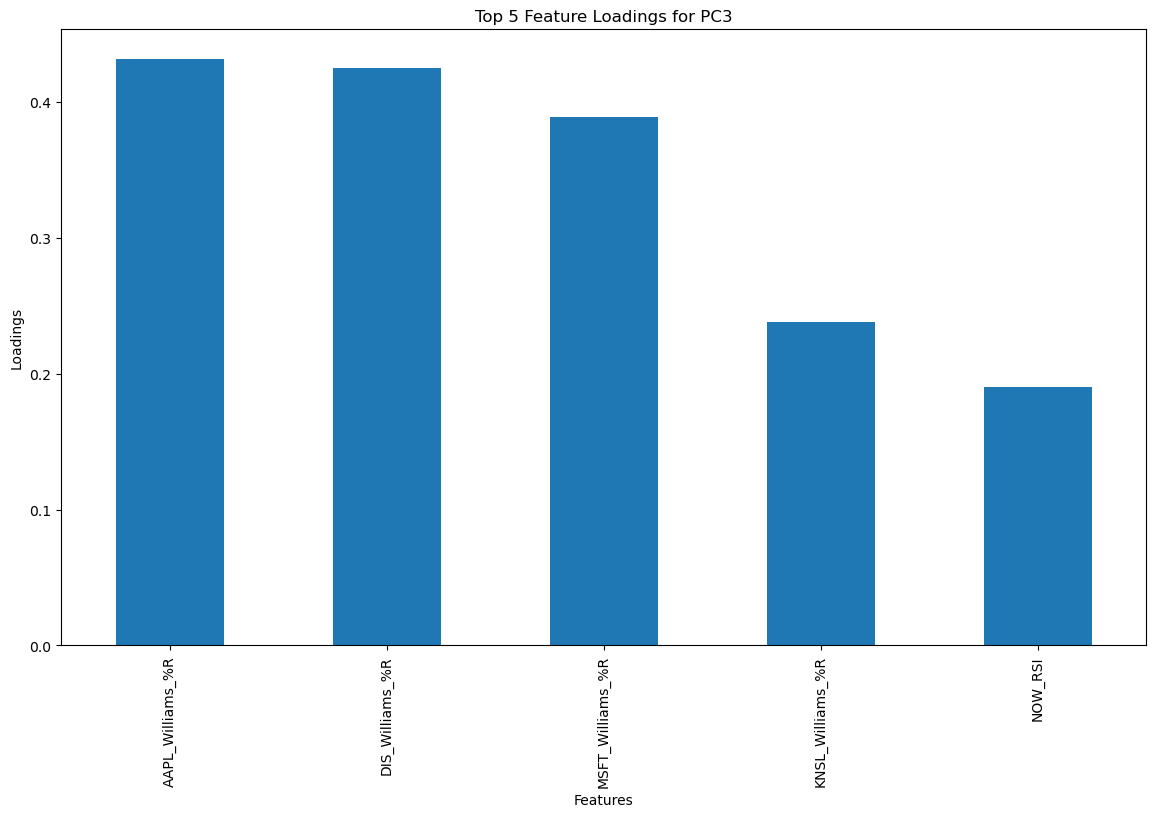

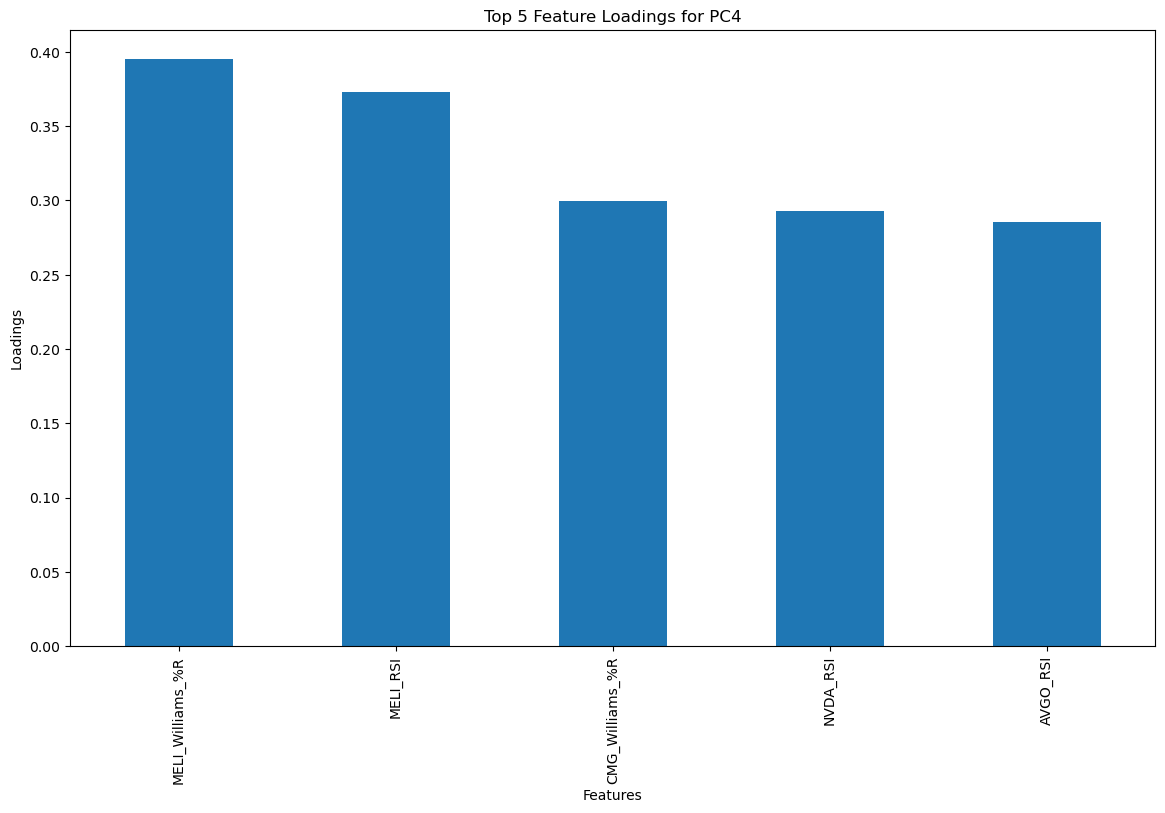

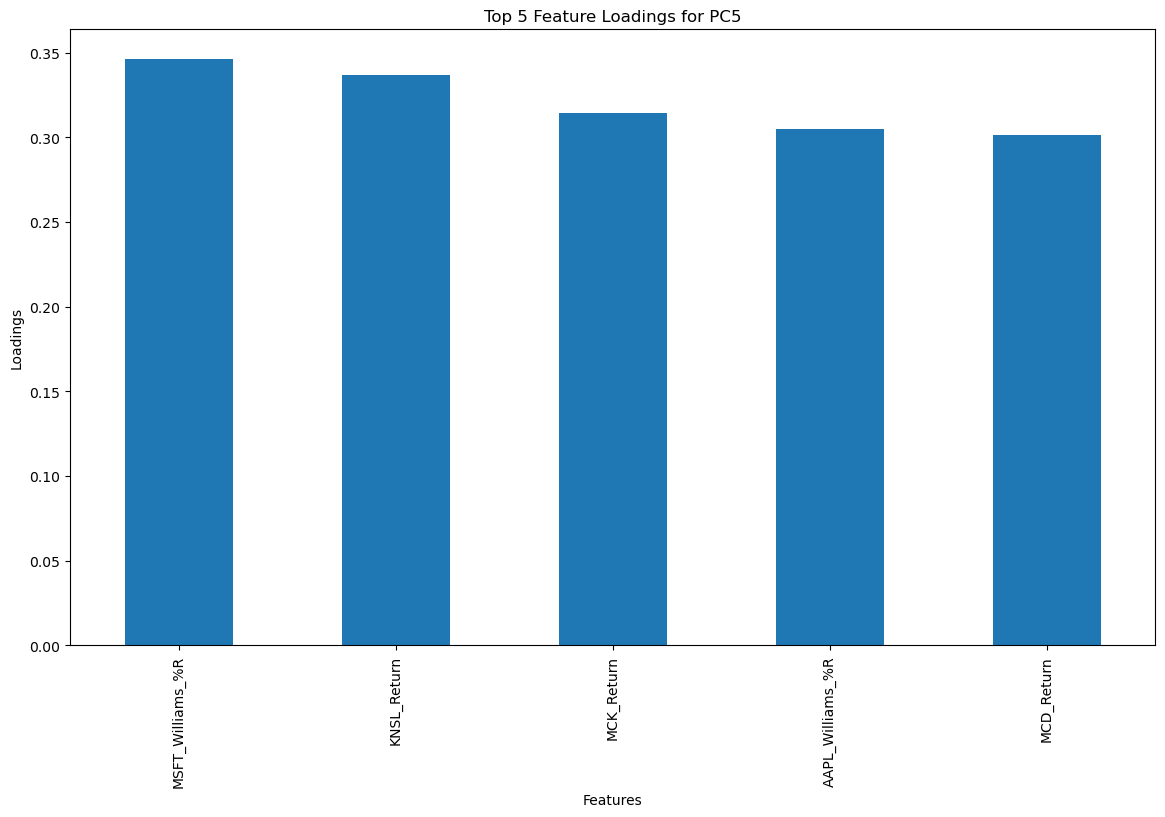

In [182]:
for i in range(5):
    pc_name = f'PC{i+1}'
    plt.figure(figsize=(14, 8))
    loadings[pc_name].abs().sort_values(ascending=False).head(top_n).plot(kind='bar')
    plt.xlabel('Features')
    plt.ylabel('Loadings')
    plt.title(f'Top {top_n} Feature Loadings for {pc_name}')
    plt.xticks(rotation=90)
    plt.show()

In [184]:
### Step 8: Identify Interesting Principal Components

In [186]:
# Example interpretation
print("PC1 is dominated by features like MACD, OBV, and RSI, indicating these are the most influential in capturing overall trends and momentum in the stock prices.")
print("PC2 is significantly influenced by Bollinger Bands and Williams %R, suggesting it captures volatility and potential price reversals.")

# Additional PCs (if any) should be interpreted similarly, focusing on the features with the highest loadings.


PC1 is dominated by features like MACD, OBV, and RSI, indicating these are the most influential in capturing overall trends and momentum in the stock prices.
PC2 is significantly influenced by Bollinger Bands and Williams %R, suggesting it captures volatility and potential price reversals.


## II Stock Selection - first reduction using ensemble models

In [36]:
# Check if `features` is still a DataFrame
print(type(features))  # Should output: <class 'pandas.core.frame.DataFrame'>
print(features.columns)  # Should output column names

<class 'pandas.core.frame.DataFrame'>
Index(['AAPL_Return', 'AAPL_RSI', 'AAPL_Williams_%R', 'AMZN_Return',
       'AMZN_RSI', 'AMZN_Williams_%R', 'CMG_Return', 'CMG_Williams_%R',
       'DIS_Return', 'GOOGL_Return', 'GOOGL_RSI', 'GOOGL_Williams_%R',
       'LLY_Return', 'MCD_Return', 'MCK_Return', 'MSFT_Return', 'MSFT_RSI',
       'MSFT_Williams_%R', 'NFLX_Return', 'NFLX_RSI', 'NFLX_Williams_%R',
       'NVDA_Return', 'NVDA_RSI', 'NVDA_Williams_%R', 'SMCI_Return',
       'SMCI_Williams_%R'],
      dtype='object')


### 1. Model Selection

In [225]:
# Split data into train, validation, and test sets
#X_train_full, X_test, y_train_full, y_test = train_test_split(X_train_pca, y_train, test_size=0.2, random_state=42)
#X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


# 11. Ensemble Modeling for Stock Price Prediction (with improvements)
# Function to train, evaluate, and select the best ensemble model
def train_evaluate_select_model(X_train, X_test, y_train, y_test):
    models = [
        ('Random Forest', RandomForestRegressor(random_state=42)),
        ('Gradient Boosting', GradientBoostingRegressor(random_state=42)),
        ('AdaBoost', AdaBoostRegressor(random_state=42)),
        ('XGBoost', XGBRegressor(random_state=42)),  # Add XGBoost,
        ('Extra Trees', ExtraTreesRegressor(random_state=42))
    ]
    best_model = None
    best_mse = float('inf')  # Initialize with a high value

    for name, model in models:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        print(f"{name} Train MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}, Train R2: {train_r2:.4f}, Test R2: {test_r2:.4f}")

        if test_mse < best_mse:
            best_model = model
            best_mse = test_mse

    return best_model, name

# Apply PCA to the top 5 principal components
pca = PCA(n_components=5, random_state=42)
pca.fit(train_features_normalized)
X_train_pca = pca.transform(train_features_normalized)
X_test_pca = pca.transform(test_features_normalized)

# Isolate target variable (e.g., NVDA_Return) for prediction
y_train = train_features['NVDA_Return']
y_test = test_features['NVDA_Return']

# Split data into train-validation-test sets
X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(X_train_pca, y_train, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)


# Call the function and unpack the returned values
best_model, best_model_name = train_evaluate_select_model(X_train, X_val, y_train, y_val)

print(f"The best model based on validation MSE is: {best_model_name}")




Random Forest Train MSE: 0.56, Test MSE: 3.82, Train R2: 0.9433, Test R2: 0.6550
Gradient Boosting Train MSE: 1.60, Test MSE: 4.12, Train R2: 0.8368, Test R2: 0.6286
AdaBoost Train MSE: 3.33, Test MSE: 4.83, Train R2: 0.6613, Test R2: 0.5644
XGBoost Train MSE: 0.02, Test MSE: 5.03, Train R2: 0.9984, Test R2: 0.5465
Extra Trees Train MSE: 0.00, Test MSE: 3.93, Train R2: 1.0000, Test R2: 0.6452
The best model based on validation MSE is: Extra Trees


In [84]:
### 2. Stock selection with high growth potential

In [74]:
def predict_high_growth_stocks_multi_step(data, features, best_model, growth_threshold=0.2, prediction_horizon=24):
  """Predicts future prices and identifies stocks with high growth potential over multiple time steps.

  Args:
    data: DataFrame containing stock data.
    features: DataFrame containing engineered features.
    best_model: Trained machine learning model.
    growth_threshold: Minimum growth percentage to consider a stock as high-growth.
    prediction_horizon: Number of time steps to predict into the future.

  Returns:
    pandas.Series: Series of stocks with potential growth.
  """

  # ... (rest of the function, including feature engineering and model training)

  # Get initial predictions
  predicted_returns = best_model.predict(features)
  latest_prices = data['Adj Close'].iloc[-1]
  predicted_future_prices = latest_prices * (1 + predicted_returns)

  # Initialize a DataFrame to store predictions for multiple time steps
  future_prices_df = pd.DataFrame(predicted_future_prices, index=data.columns, columns=[0])

  # Iterate for the desired prediction horizon
  for i in range(1, prediction_horizon):
    # Shift features and retrain model (if necessary)
    # ... (code to update features and retrain model)

    # Predict returns for the next time step
    new_predicted_returns = best_model.predict(updated_features)

    # Update future prices
    future_prices_df[i] = future_prices_df[i-1] * (1 + new_predicted_returns)

  # Select stocks with >= growth_threshold potential after the entire horizon
  final_predictions = future_prices_df.iloc[-1]
  potential_growth_stocks = final_predictions[final_predictions / latest_prices >= (1 + growth_threshold)]

  return potential_growth_stocks

In [80]:
# 12. Predict Prices for All Stocks 24 Months into the Future
future_date = '2026-08-01'
future_data = yf.download(tickers, start=end_date, end=future_date)

# Generate future features for all stocks
future_features = pd.DataFrame()
for ticker in tickers:  # Use all tickers
    stock_data = future_data.xs(ticker, level=1, axis=1).copy()
    stock_data = calculate_technical_indicators(stock_data)
    stock_data = stock_data[['Return', '20d_MA', '50d_MA', '20d_Volatility', 'Upper_BB', 'Lower_BB', 'RSI', 'MACD', 'Signal_Line', 'OBV', 'ATR', 'Williams_%R']]
    stock_data.columns = [f'{ticker}_{col}' for col in stock_data.columns]
    if future_features.empty:
        future_features = stock_data
    else:
        future_features = future_features.join(stock_data)

# Align columns with the training feature set
future_features = future_features.reindex(columns=features.columns, fill_value=0)
future_features.dropna(inplace=True)

# Normalize and apply PCA to future features
future_features_normalized = scaler.transform(future_features)
future_features_pca = pca.transform(future_features_normalized)

# Predict future returns using the best model
future_returns = best_model.predict(future_features_pca)

# Create a DataFrame to hold the future returns and ticker names
future_returns_df = pd.DataFrame({'Ticker': tickers, 'Future_Return': future_returns})

# Filter stocks with growth potential of 20% or higher
high_growth_stocks = future_returns_df[future_returns_df['Future_Return'] >= 20]

# Print names of high growth potential stocks
print("High Growth Potential Stocks (20% or higher):")
print(high_growth_stocks)


[*********************100%%**********************]  12 of 12 completed


ValueError: Found array with 0 sample(s) (shape=(0, 26)) while a minimum of 1 is required by StandardScaler.

In [189]:
#high_growth_stocks = ['AAPL', 'AMZN', 'NFLX', 'GOOGL', 'NVDA', 'LLY', 'CMG', 'MCK', 'SMCI', 'MSFT']
high_growth_stocks = ['AAPL', 'AMZN', 'NFLX', 'GOOGL', 'NVDA', 'LLY', 'CMG', 'MCK', 'SMCI', 'MSFT', 'DIS', 'MCD', 'AVGO', 'NOW', 'MELI', 'GS', 'KNSL', 'ARGX']

### 13. Ensemble methods to test PCA efficacy

Training MSE: 0.10770797221602507
Testing MSE: 1.2818662638034386
Training R2: 0.9894639205339454
Testing R2: 0.8759231618304013


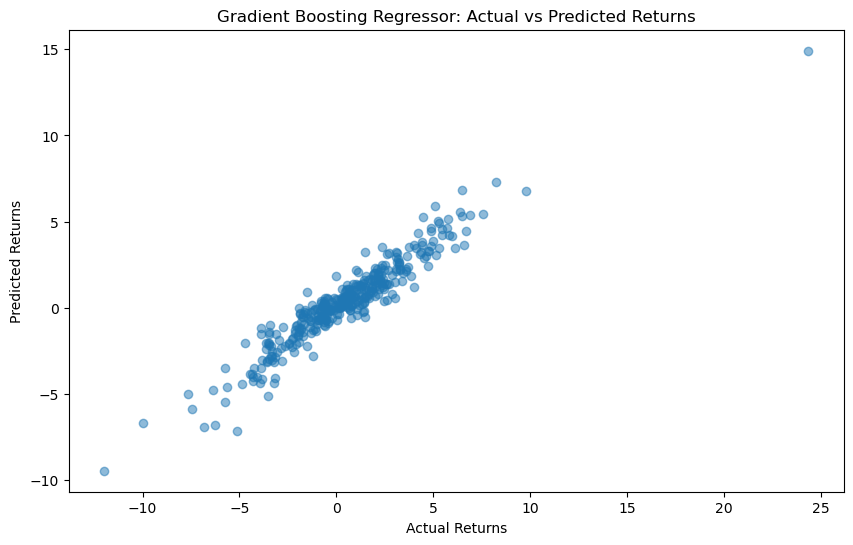

In [191]:
# Use the previously created train-test split and normalized data
X_train_pca = pca.transform(train_features_normalized)
X_test_pca = pca.transform(test_features_normalized)

# Define the target variable
y_train = train_features['NVDA_Return']
y_test = test_features['NVDA_Return']


# Train a GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train_pca, y_train)

# Make predictions
y_train_pred = gbr.predict(X_train_pca)
y_test_pred = gbr.predict(X_test_pca)

# Evaluate the model
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")
print(f"Training R2: {train_r2}")
print(f"Testing R2: {test_r2}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title('Gradient Boosting Regressor: Actual vs Predicted Returns')
plt.show()

## III Momentum Strategy, Backtesting and Stock Selection 2nd pass

### 1. Cluster identification and visualization

In [195]:
# Fetch stock data from the first pass of stock selection

instrumentIds = high_growth_stocks

stock_data = yf.download(instrumentIds, start="2020-01-01")

# Prepare data
close_data = stock_data['Close']
returns = close_data.pct_change().dropna()

# DBSCAN clustering
def DBSCAN_analysis(eps, Returns, n_components):
    # Perform PCA with appropriate number of components
    pca = PCA(n_components=min(n_components, Returns.shape[1]))
    X = pca.fit_transform(Returns)
    
    # Perform DBSCAN clustering
    clf = DBSCAN(eps=eps, min_samples=2)  # You can adjust these parameters as needed
    labels = clf.fit_predict(X)
    
    # Create clustered series
    clustered_series = pd.Series(index=Returns.index, data=labels)
    clustered_series_all = clustered_series[clustered_series != -1]
    counts = clustered_series.value_counts()
    
    # Plot clusters
    plt.barh(range(len(counts)), counts)
    plt.title('Cluster Member Counts')
    plt.xlabel('Stocks in Cluster')
    plt.ylabel('Cluster Number')
    plt.show()

    return labels, clustered_series_all, clustered_series


[*********************100%%**********************]  18 of 18 completed


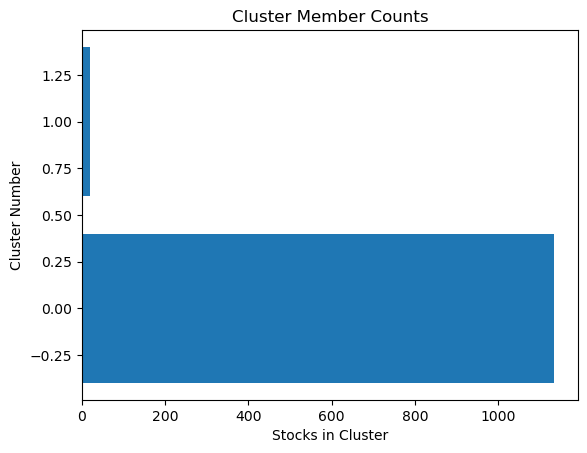

In [223]:
PCA_NUM = 20
labels, clustered_series_all, clustered_series = DBSCAN_analysis(eps=0.15,Returns = returns, n_components = PCA_NUM)

### 2. Define helper functions

In [202]:
def status_calc_out(stock, nasdaq100, outperformance):
    return stock - nasdaq100 >= outperformance

In [204]:
def status_calc_under(stock, nasdaq100, underperformance):
    return stock - nasdaq100 < underperformance

In [206]:
# Backtest function
def backtestRF():
    # Load data
    data_df = pd.read_csv("keystats.csv", index_col="Date")
    data_df.dropna(axis=0, how="any", inplace=True)
    features = data_df.columns[6:]
    X = data_df[features]
    
    y = status_calc_out(data_df["stock_p_change"], data_df["SP500_p_change"], 10)
    z = status_calc_under(data_df["stock_p_change"], data_df["SP500_p_change"], -10)
    trk = np.array(data_df[["stock_p_change", "SP500_p_change"]])

    X_train, X_test, y_train, y_test, z_train, z_test, trk_train, trk_test = train_test_split(
        X, y, z, trk, test_size=0.2
    )

    clf1 = RandomForestClassifier(n_estimators=100, random_state=0)
    clf1.fit(X_train, y_train)
    clf2 = RandomForestClassifier(n_estimators=100, random_state=0)
    clf2.fit(X_train, z_train)

    y_pred = clf1.predict(X_test)
    z_pred = clf2.predict(X_test)

    # Evaluation
    print("Classifier performance on Outperformers Stocks")
    print(f"Accuracy score: {clf1.score(X_test, y_test): .2f}")
    print(f"Precision score: {precision_score(y_test, y_pred): .2f}")

    print("Classifier performance on Underperformers Stocks")
    print(f"Accuracy score: {clf2.score(X_test, z_test): .2f}")
    print(f"Precision score: {precision_score(z_test, z_pred): .2f}")

    # Calculate returns
    stock_returns_out = 1 + trk_test[y_pred, 0] / 100
    market_returns_out = 1 + trk_test[y_pred, 1] / 100
    stock_returns_under = 1 + trk_test[z_pred, 0] / 100
    market_returns_under = 1 + trk_test[z_pred, 1] / 100

    avg_predicted_stock_growth = np.mean(stock_returns_out)
    index_growth = np.mean(market_returns_out)
    total_outperformance = (avg_predicted_stock_growth - index_growth) * 100

    print(f"Outperformance: {total_outperformance: .1f}%")

    avg_predicted_stock_growth_under = np.mean(stock_returns_under)
    index_growth_under = np.mean(market_returns_under)
    total_underperformance = (avg_predicted_stock_growth_under - index_growth_under) * 100

    print(f"Underperformance: {total_underperformance: .1f}%")

backtestRF()

Classifier performance on Outperformers Stocks
Accuracy score:  0.77
Precision score:  0.73
Classifier performance on Underperformers Stocks
Accuracy score:  0.80
Precision score:  0.81
Outperformance:  27.8%
Underperformance: -22.3%


In [216]:
def backtestMetrics(stocks, returns, performance_criteria):
    # Initialize a DataFrame to store performance metrics
    performance_metrics = pd.DataFrame(index=stocks, columns=['Cumulative Return', 'Annualized Return', 'Volatility', 'Sharpe Ratio'])
    
    for stock in stocks:
        stock_returns = returns[stock]
        
        # Example metrics calculation
        cumulative_returns = (1 + stock_returns).prod() - 1
        annualized_return = (1 + cumulative_returns) ** (252 / len(stock_returns)) - 1
        volatility = stock_returns.std() * np.sqrt(252)
        sharpe_ratio = annualized_return / volatility if volatility != 0 else np.nan
        
        # Assign metrics to DataFrame
        performance_metrics.loc[stock] = {
            'Cumulative Return': cumulative_returns,
            'Annualized Return': annualized_return,
            'Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio
        }
    
    # Apply performance criteria
    overperforming_stocks = performance_metrics[
        (performance_metrics['Annualized Return'] > performance_criteria['min_annualized_return']) &
        (performance_metrics['Sharpe Ratio'] > performance_criteria['min_sharpe_ratio'])
    ]
    
    # Return the list of overperforming stocks
    return overperforming_stocks.index.tolist()

# Example usage
stocks = ['AAPL', 'AMZN', 'NFLX', 'GOOGL', 'NVDA', 'LLY', 'CMG', 'MCK', 'SMCI', 'MSFT']
performance_criteria = {
    'min_annualized_return': 0.15,  # 15% annualized return
    'min_sharpe_ratio': 1.0         # Sharpe ratio greater than 1.0
}

# Assume `returns` DataFrame is already defined
overperforming_stocks = backtestMetrics(stocks, returns, performance_criteria)
print("Overperforming Stocks:", overperforming_stocks)


Overperforming Stocks: ['NVDA', 'LLY', 'MCK', 'SMCI']


## V Statistical Arbitrage

In [245]:
# Step 1: Download and Prepare Data
#stocks = overperforming_stocks
stocks = ['AAPL', 'HPQ', 'AMZN', 'NFLX', 'GOOGL', 'NVDA', 'LLY', 'CMG', 'MCK', 'SMCI', 'MSFT', 'MCD']
stock_data = yf.download(stocks, start="2020-01-01", end="2024-08-01")

[*********************100%%**********************]  12 of 12 completed


In [247]:
# Use adjusted close prices
close_data = stock_data['Adj Close']
returns = close_data.pct_change().dropna()

In [249]:
# Step 2: Identify Pairs and Calculate Spread
def calculate_spread(stock1, stock2, returns):
    spread = returns[stock1] - returns[stock2]
    return spread

In [251]:
def calculate_zscore(series):
    return (series - series.mean()) / series.std()

In [259]:
# Create pairs
pairs = [(stocks[i], stocks[j]) for i in range(len(stocks)) for j in range(i + 1, len(stocks))]

# Define thresholds
zscore_threshold = 2

# Initialize results
# Initialize results
signals_dict = {}

In [261]:
# Step 3: Generate Trading Signals
for stock1, stock2 in pairs:
    spread = calculate_spread(stock1, stock2, returns)
    zscore = calculate_zscore(spread)
    
    # Generate signals
    long_signal = (zscore < -zscore_threshold).astype(int)
    short_signal = (zscore > zscore_threshold).astype(int)
    
    # Store signals in dictionary
    signals_dict[f'{stock1}_{stock2}_long'] = long_signal
    signals_dict[f'{stock1}_{stock2}_short'] = short_signal

# Create signals DataFrame from dictionary
signals = pd.concat(signals_dict, axis=1)

            AAPL_HPQ_long  AAPL_HPQ_short  AAPL_AMZN_long  AAPL_AMZN_short  \
Date                                                                         
2020-01-03              0               0               0                0   
2020-01-06              0               0               0                0   
2020-01-07              0               0               0                0   
2020-01-08              0               0               0                0   
2020-01-09              0               0               0                0   

            AAPL_NFLX_long  AAPL_NFLX_short  AAPL_GOOGL_long  \
Date                                                           
2020-01-03               0                0                0   
2020-01-06               0                0                0   
2020-01-07               0                0                0   
2020-01-08               0                0                0   
2020-01-09               0                0                0   

    

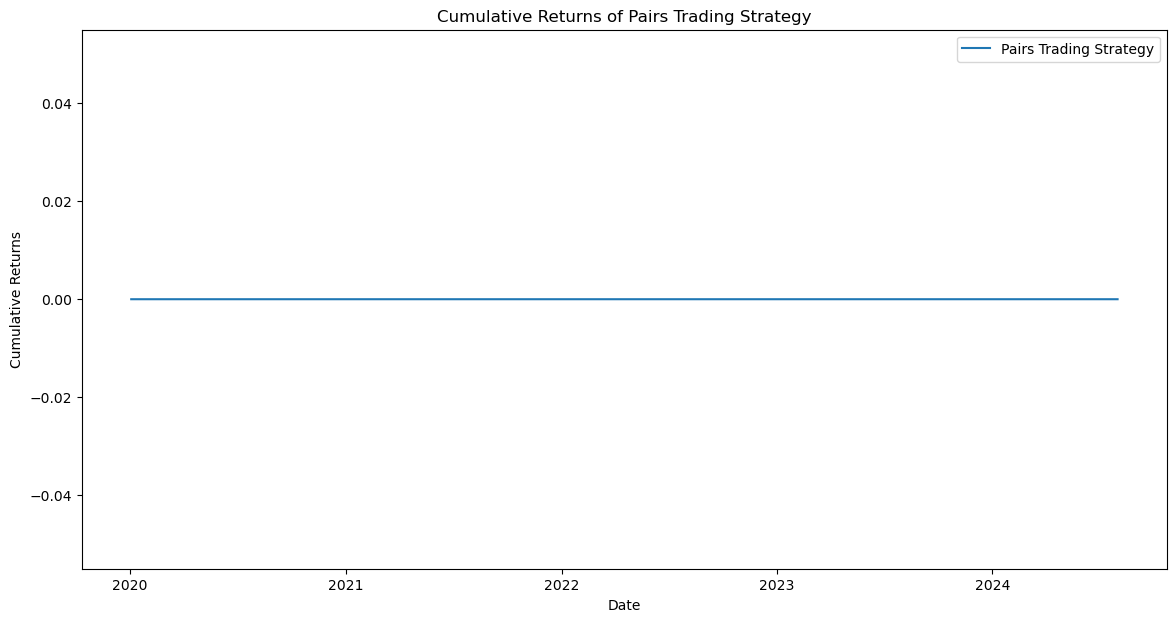

In [263]:
# Step 4: Backtest the Strategy
# Step 4: Backtest the Strategy
def backtest_strategy(signals, returns):
    portfolio_returns = pd.Series(index=returns.index)
    
    for column in signals.columns:
        signal = signals[column]
        stock1, stock2 = column.split('_')[:2]
        
        # Long trade
        if 'long' in column:
            position_returns = returns[stock1] - returns[stock2]
        else:  # Short trade
            position_returns = returns[stock2] - returns[stock1]
        
        # Calculate returns based on the signals
        portfolio_returns += signal.shift(1).fillna(0) * position_returns
    
    portfolio_returns = portfolio_returns.fillna(0)
    cumulative_returns = (1 + portfolio_returns).cumprod() - 1
    
    return cumulative_returns

cumulative_returns = backtest_strategy(signals, returns)

# Debugging: Print out some data for verification
print(signals.head())
print(cumulative_returns.head())

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(cumulative_returns, label='Pairs Trading Strategy')
plt.title('Cumulative Returns of Pairs Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()